In [220]:
import pandas as pd

df = pd.read_csv("final_dataset.csv")

In [221]:
religion = ["christianity", "judaism", "islam", "buddhism", "hindu", "shinto", "confus_tao"]
df["dominant_religion"] = df[religion].idxmax(axis=1)
df[["country", "year", "dominant_religion", "gdp"]]

,country,year,dominant_religion,gdp
0,United States,1990,christianity,5.963144e+12
1,United States,1995,christianity,7.639749e+12
2,United States,2000,christianity,1.025095e+13
3,United States,2005,christianity,1.303920e+13
4,United States,2010,christianity,1.504896e+13
...,...,...,...,...
774,Samoa,1990,christianity,1.257663e+08
775,Samoa,1995,christianity,2.248657e+08
776,Samoa,2000,christianity,2.588561e+08
777,Samoa,2005,christianity,4.768018e+08


In [222]:
religion_yearly = df.groupby("year")[religion].sum()

# Convert to percentage share
religion_yearly_pct = religion_yearly.div(religion_yearly.sum(axis=1), axis=0) * 100

religion_yearly_pct.head()

,christianity,judaism,islam,buddhism,hindu,shinto,confus_tao
year,,,,,,,
1990,44.165148,0.426672,23.084152,10.337594,19.042876,2.732251,0.211307
1995,43.361016,0.365972,24.417228,10.280595,18.849237,2.515451,0.210502
2000,41.888870,0.318714,25.529930,8.787008,20.923130,2.323624,0.228725
2005,40.535167,0.313852,25.728973,9.942549,20.902658,2.366722,0.210081
2010,40.241528,0.289828,26.316091,9.606978,21.086431,2.246480,0.212664


In [223]:
avg_gdp_by_religion = df.groupby("dominant_religion")["gdp"].mean() # avg GDP by religion
print(avg_gdp_by_religion)

dominant_religion
buddhism        2.957765e+11
christianity    2.731741e+11
hindu           2.474362e+11
islam           4.665731e+10
judaism         1.382451e+11
shinto          4.858073e+12
Name: gdp, dtype: float64


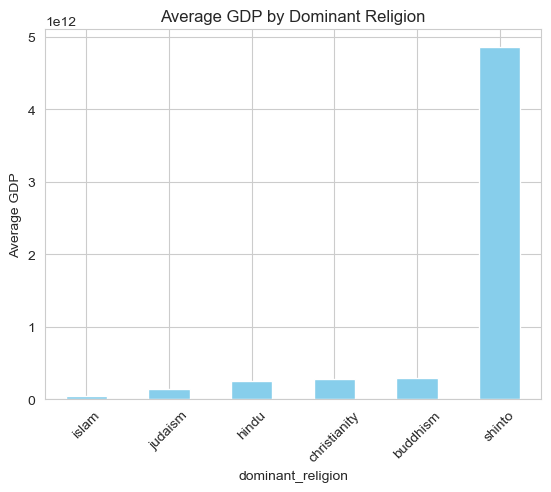

In [224]:
# 1
import matplotlib.pyplot as plt

avg_gdp_by_religion.sort_values().plot(kind="bar", color="skyblue")
plt.ylabel("Average GDP")
plt.title("Average GDP by Dominant Religion")
plt.xticks(rotation=45)
plt.show()

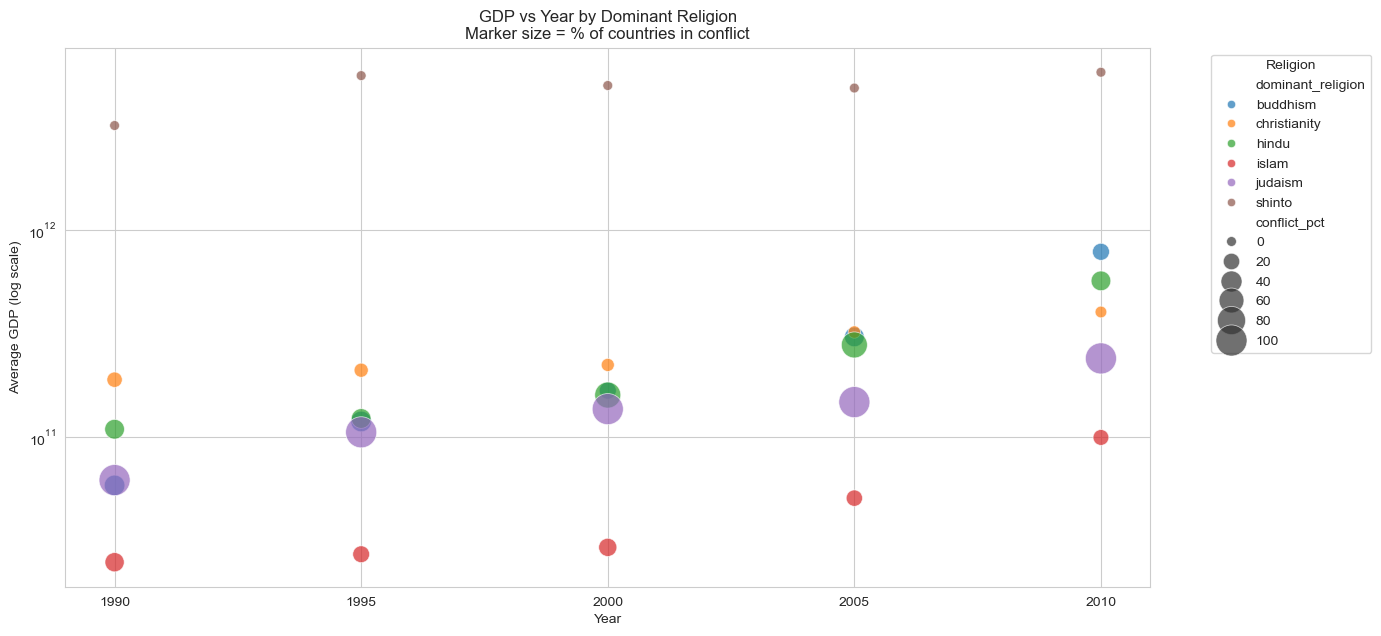

In [225]:
#2
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))

# GDP vs year
sns.scatterplot(
    data=agg_df,
    x="year",
    y="avg_gdp",
    hue="dominant_religion",       # color by religion
    size="conflict_pct",           # size by % of countries in conflict
    sizes=(50, 500),               # min/max size of markers
    alpha=0.7
)

plt.yscale("log")

plt.xlabel("Year")
plt.xticks(agg_df['year'].unique())
plt.ylabel("Average GDP (log scale)")
plt.title("GDP vs Year by Dominant Religion\nMarker size = % of countries in conflict")
plt.legend(title="Religion", bbox_to_anchor=(1.05, 1), loc=2) 
plt.show()

<Figure size 1200x600 with 0 Axes>

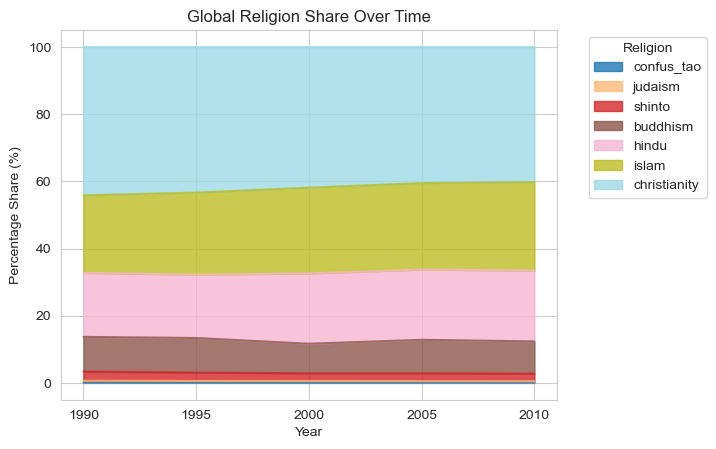

In [226]:
#3
import matplotlib.pyplot as plt
religion_yearly_pct = religion_yearly.div(religion_yearly.sum(axis=1), axis=0) * 100

# Sort columns so the smallest total religion is first (bottom of stacked area)
sorted_cols = religion_yearly_pct.sum().sort_values().index
religion_yearly_pct = religion_yearly_pct[sorted_cols]

plt.figure(figsize=(12,6))
religion_yearly_pct.plot(kind="area", stacked=True, cmap="tab20", alpha=0.8)

plt.ylabel("Percentage Share (%)")
plt.xlabel("Year")
plt.xticks(agg_df['year'].unique())
plt.title("Global Religion Share Over Time")
plt.legend(title="Religion", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

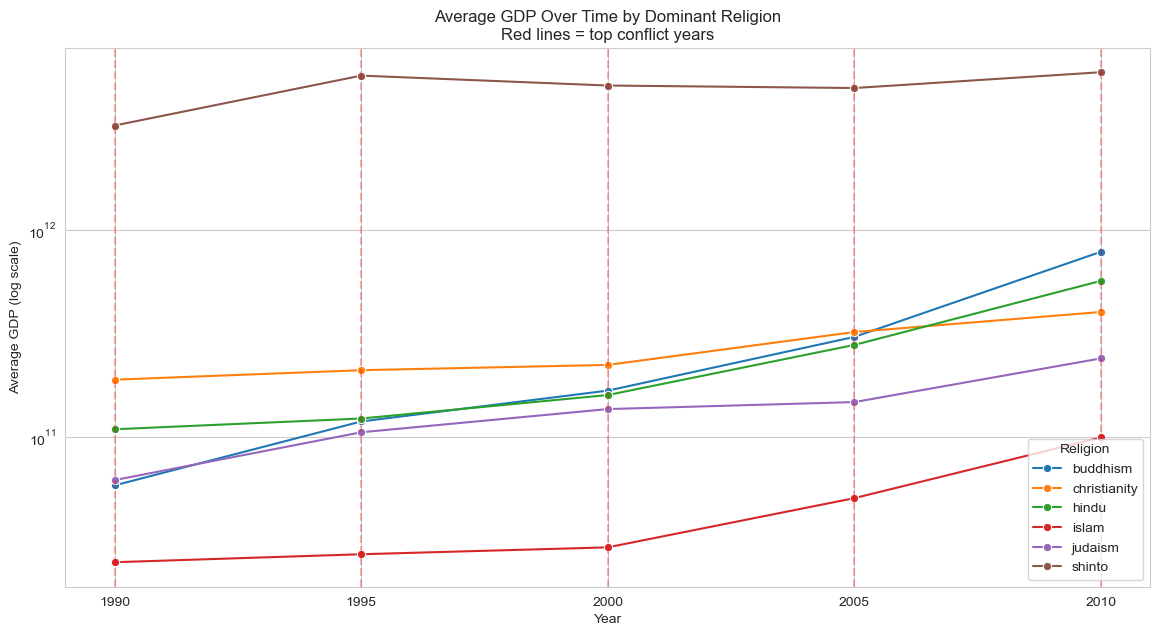

In [227]:
#4
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))

sns.lineplot(
    data=agg_df,
    x="year",
    y="avg_gdp",
    hue="dominant_religion",
    marker="o"
)

year_conflict_avg = agg_df.groupby("year")["conflict_pct"].mean()
high_conflict_years = year_conflict_avg.sort_values(ascending=False).head(10).index

for year in high_conflict_years:
    plt.axvline(x=int(year), color="red", linestyle="--", alpha=0.3)

plt.yscale("log")
plt.title("Average GDP Over Time by Dominant Religion\nRed lines = top conflict years")
plt.xlabel("Year")
plt.xticks(agg_df['year'].unique())
plt.ylabel("Average GDP (log scale)")
plt.legend(title="Religion")
plt.show()

In [228]:
#5
import pandas as pd

religion = ["christianity", "judaism", "islam", "buddhism", "hindu", "shinto", "confus_tao"]

# Countries with conflict
conflict_df = df[df["conflict_present"] == 1]

conflict_yearly = conflict_df.groupby("year")[religion].sum()

conflict_pct = conflict_yearly.div(conflict_yearly.sum(axis=1), axis=0) * 100


# Countries without conflict
no_conflict_df = df[df["conflict_present"] == 0]

no_conflict_yearly = no_conflict_df.groupby("year")[religion].sum()

no_conflict_pct = no_conflict_yearly.div(no_conflict_yearly.sum(axis=1), axis=0) * 100

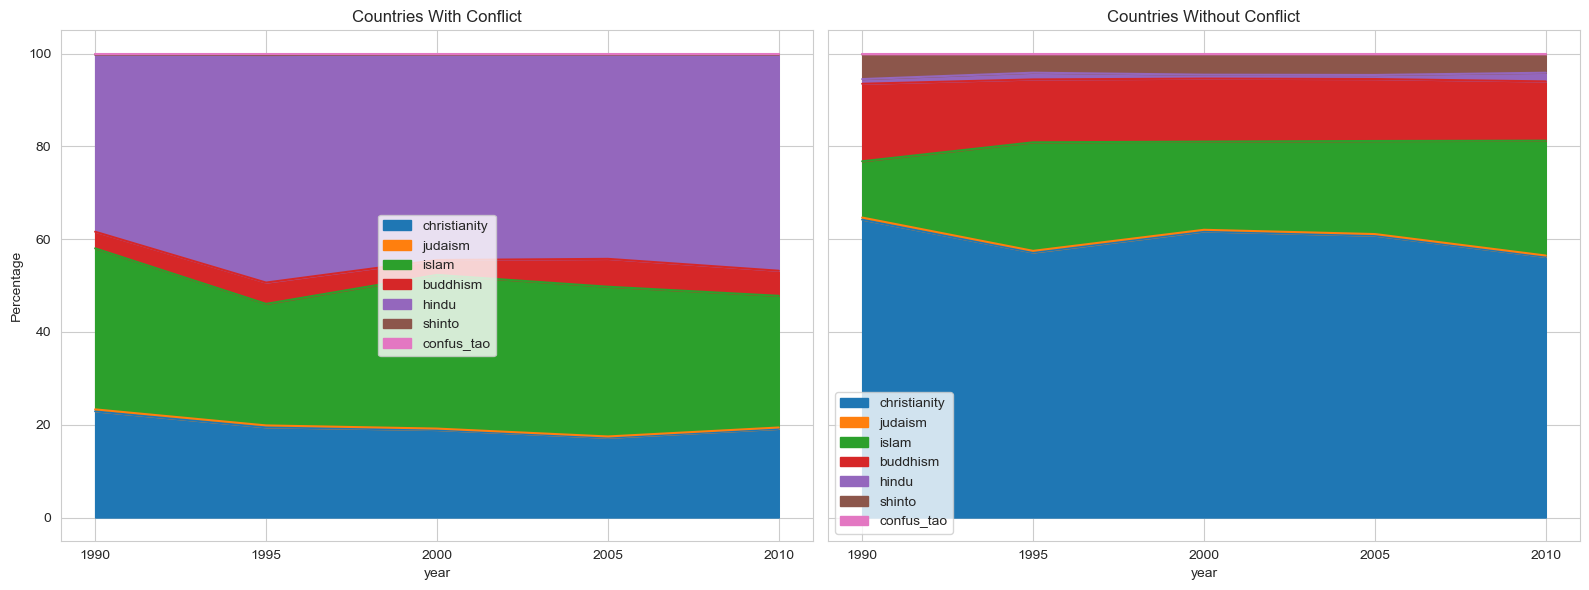

In [232]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=True)

# Countries with conflict
conflict_pct.plot(kind="area", stacked=True, ax=axes[0])
axes[0].set_title("Countries With Conflict")
axes[0].set_ylabel("Percentage")
axes[0].set_xticks(conflict_pct.index)  # force integer years

# Countries without conflict
no_conflict_pct.plot(kind="area", stacked=True, ax=axes[1])
axes[1].set_title("Countries Without Conflict")
axes[1].set_xticks(no_conflict_pct.index)  # force integer years

plt.tight_layout()
plt.show()

In [230]:
# 6 # Conflict countries
conflict_gdp = df[df["conflict_present"] == 1] \
    .groupby(["year","dominant_religion"])["gdp"] \
    .mean() \
    .reset_index()

# Non-conflict countries
no_conflict_gdp = df[df["conflict_present"] == 0] \
    .groupby(["year","dominant_religion"])["gdp"] \
    .mean() \
    .reset_index()

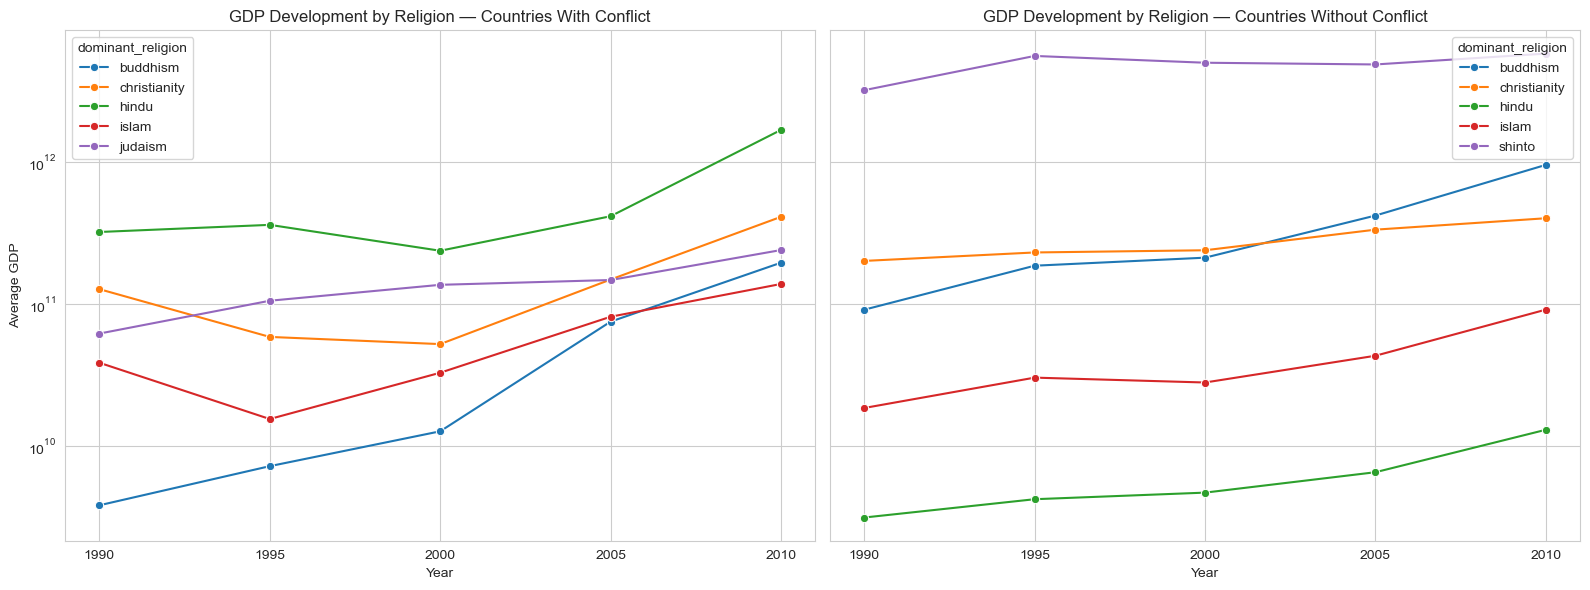

In [233]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=True)

# Conflict countries
sns.lineplot(
    data=conflict_gdp,
    x="year",
    y="gdp",
    hue="dominant_religion",
    marker="o",
    ax=axes[0]
)

axes[0].set_title("GDP Development by Religion — Countries With Conflict")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Average GDP")
axes[0].set_yscale("log")
axes[0].set_xticks(conflict_gdp['year'].unique())  # force integer years

# Non-conflict countries
sns.lineplot(
    data=no_conflict_gdp,
    x="year",
    y="gdp",
    hue="dominant_religion",
    marker="o",
    ax=axes[1]
)

axes[1].set_title("GDP Development by Religion — Countries Without Conflict")
axes[1].set_xlabel("Year")
axes[1].set_yscale("log")
axes[1].set_xticks(no_conflict_gdp['year'].unique())  # force integer years

plt.tight_layout()
plt.show()

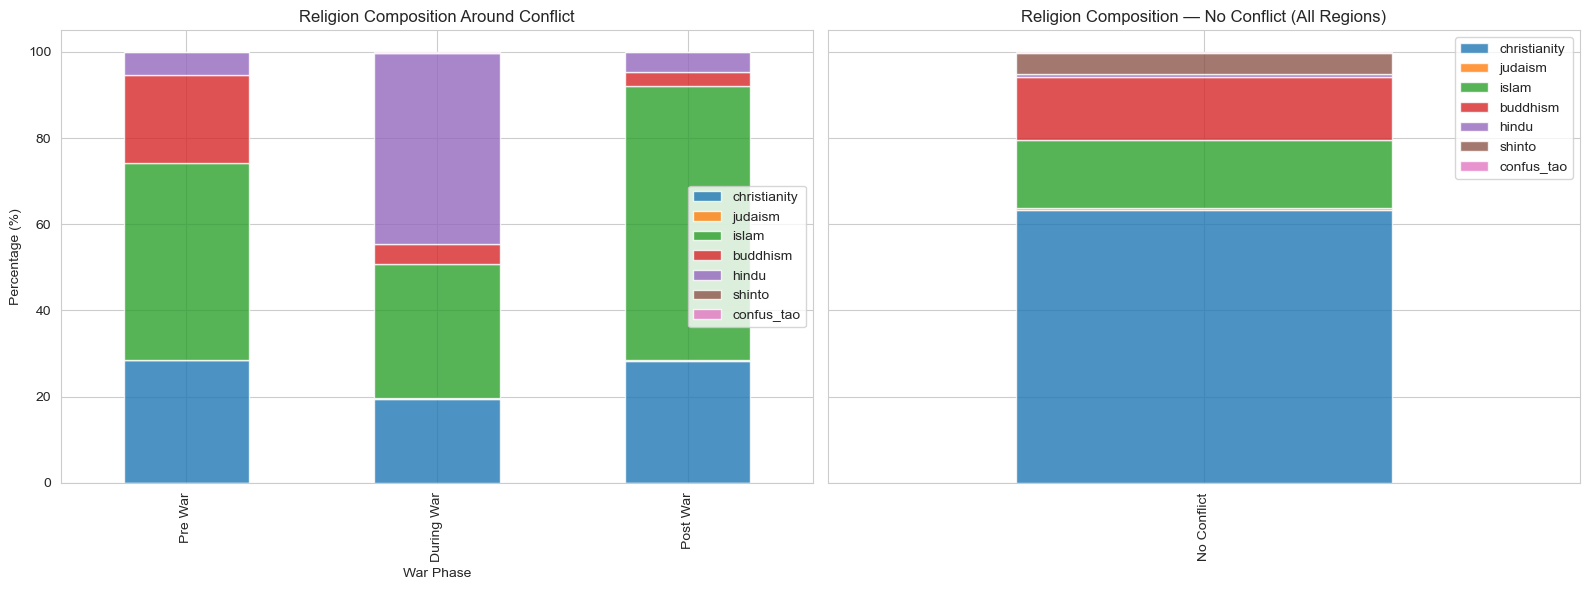

In [158]:
#7
religion = ["christianity", "judaism", "islam", "buddhism", "hindu", "shinto", "confus_tao"]

df["dominant_religion"] = df[religion].idxmax(axis=1)

# Sort by country and year for war phase
df = df.sort_values(["country","year"])
df["conflict_prev"] = df.groupby("country")["conflict_present"].shift(1)
df["conflict_next"] = df.groupby("country")["conflict_present"].shift(-1)

# Define war phases
def war_phase(row):
    if row["conflict_present"] == 1:
        return "During War"
    elif row["conflict_prev"] == 1:
        return "Post War"
    elif row["conflict_next"] == 1:
        return "Pre War"
    else:
        return "No Conflict"

df["war_phase"] = df.apply(war_phase, axis=1)

# Aggregate religion counts per war phase
religion_phase = df.groupby("war_phase")[religion].sum()

religion_phase_pct = religion_phase.div(religion_phase.sum(axis=1), axis=0) * 100

# Separate war phases vs no conflict
war_phases = ["Pre War", "During War", "Post War"]
war_data = religion_phase_pct.loc[war_phases]

# For No Conflict, aggregate all regions together
no_conflict_df = df[df["war_phase"] == "No Conflict"]
no_conflict_sum = no_conflict_df[religion].sum()
no_conflict_pct = (no_conflict_sum / no_conflict_sum.sum()) * 100
no_conflict_data = pd.DataFrame([no_conflict_pct], index=["No Conflict"])

fig, axes = plt.subplots(1,2, figsize=(16,6), sharey=True)

# War phases
war_data.plot(
    kind="bar",
    stacked=True,
    alpha=0.8,
    ax=axes[0]
)
axes[0].set_title("Religion Composition Around Conflict")
axes[0].set_ylabel("Percentage (%)")
axes[0].set_xlabel("War Phase")

# No conflict (all regions)
no_conflict_data.plot(
    kind="bar",
    stacked=True,
    alpha=0.8,
    ax=axes[1]
)
axes[1].set_title("Religion Composition — No Conflict (All Regions)")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

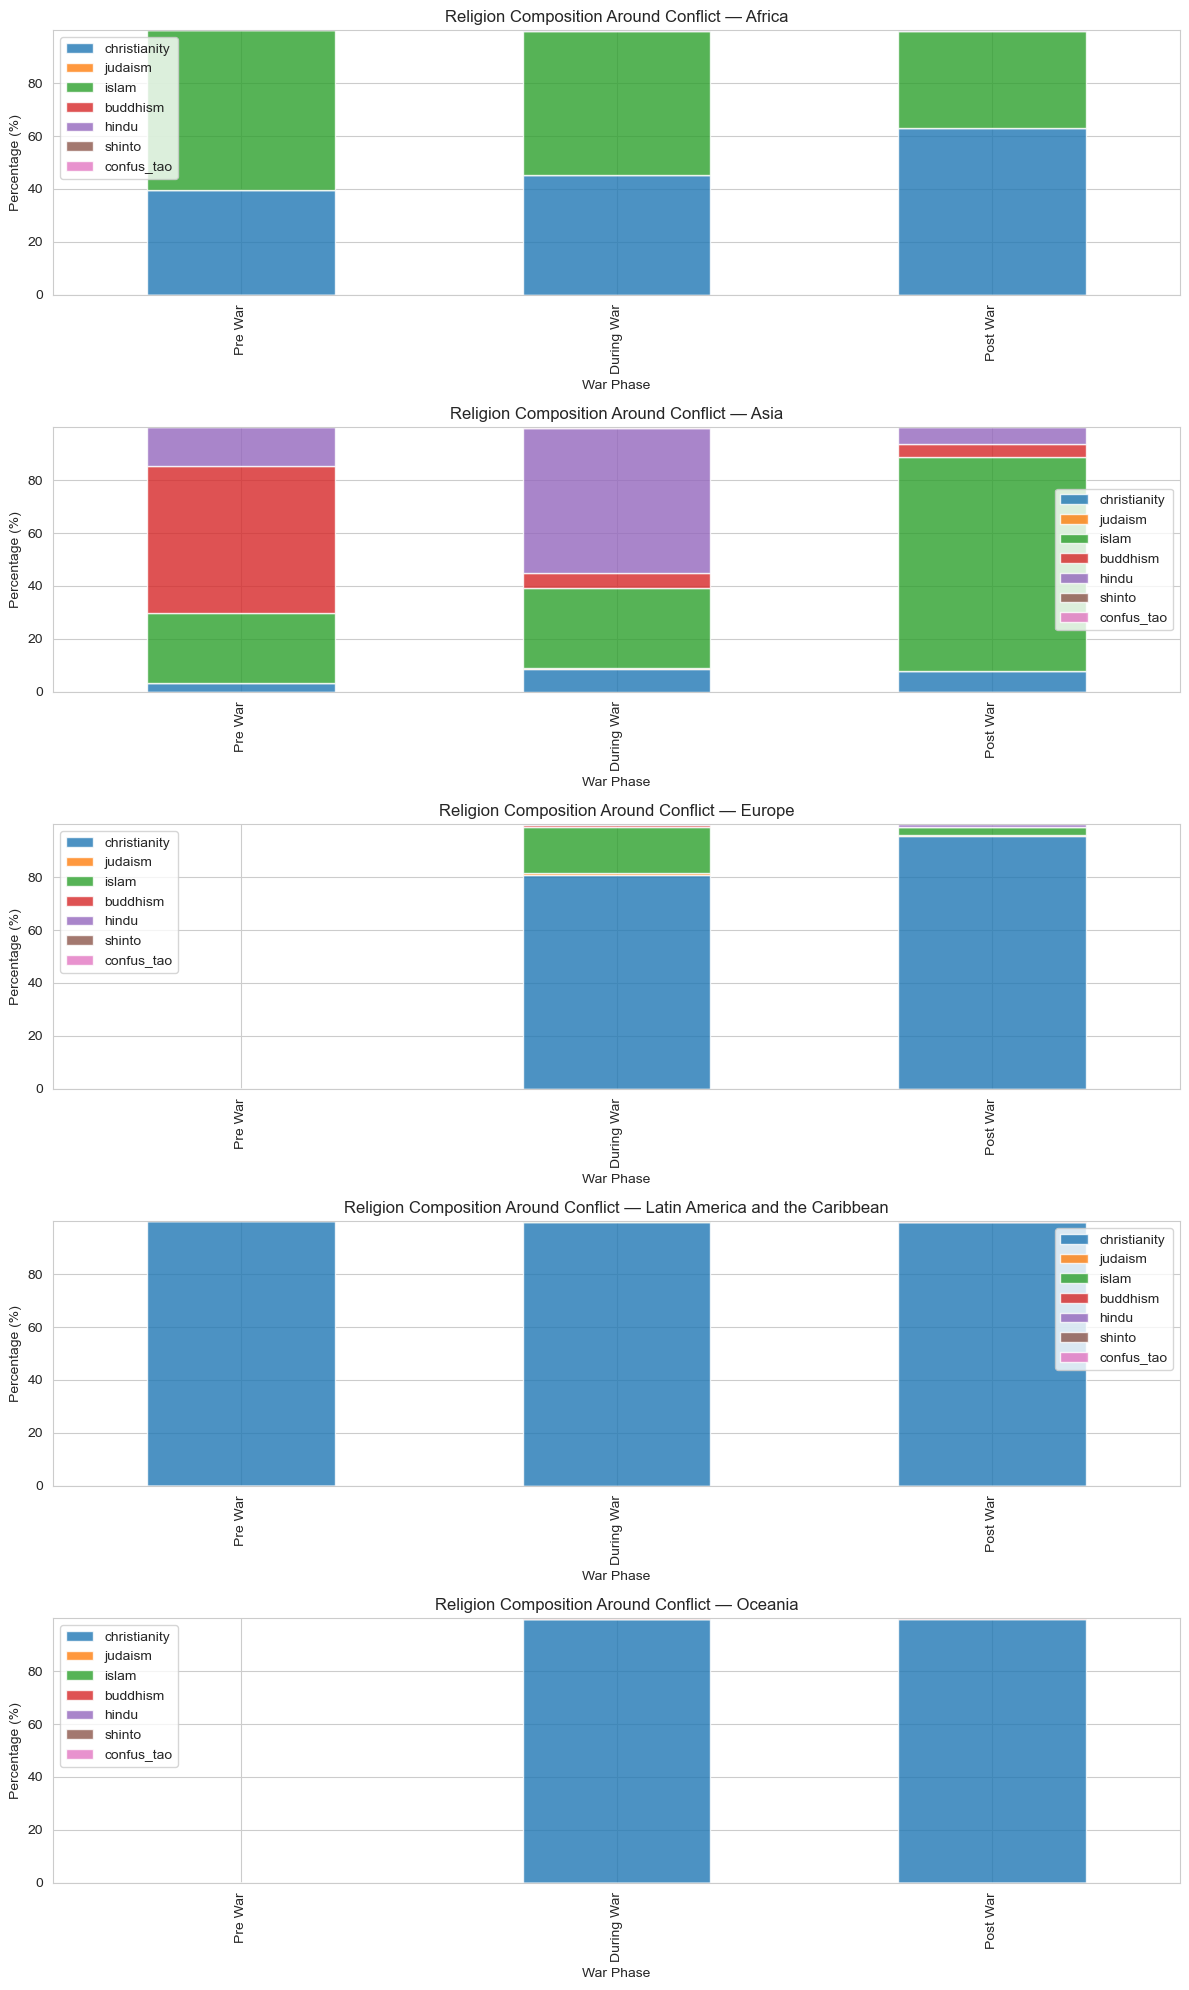

In [159]:
#8
religion = ["christianity", "judaism", "islam", "buddhism", "hindu", "shinto", "confus_tao"]

df["dominant_religion"] = df[religion].idxmax(axis=1)

df = df.sort_values(["country","year"])
df["conflict_prev"] = df.groupby("country")["conflict_present"].shift(1)
df["conflict_next"] = df.groupby("country")["conflict_present"].shift(-1)

# Define war phases
def war_phase(row):
    if row["conflict_present"] == 1:
        return "During War"
    elif row["conflict_prev"] == 1:
        return "Post War"
    elif row["conflict_next"] == 1:
        return "Pre War"
    else:
        return "No Conflict"

df["war_phase"] = df.apply(war_phase, axis=1)

# Select only conflict countries (Pre/During/Post)
war_data = df[df["war_phase"].isin(["Pre War","During War","Post War"])]

# Aggregate religion counts by war phase and region
war_region_agg = war_data.groupby(["un_region","war_phase"])[religion].sum()

# Convert to percentage share
war_region_pct = war_region_agg.div(war_region_agg.sum(axis=1), axis=0) * 100

# Plot stacked bars per region
regions = war_region_pct.index.get_level_values(0).unique()
war_phases = ["Pre War","During War","Post War"]

fig, axes = plt.subplots(len(regions), 1, figsize=(12, 4*len(regions)), sharey=True)

for i, region in enumerate(regions):
    data = war_region_pct.loc[region]
    data = data.reindex(war_phases)  
    data.plot(kind="bar", stacked=True, alpha=0.8, ax=axes[i])
    axes[i].set_title(f"Religion Composition Around Conflict — {region}")
    axes[i].set_ylabel("Percentage (%)")
    axes[i].set_xlabel("War Phase")

plt.tight_layout()
plt.show()

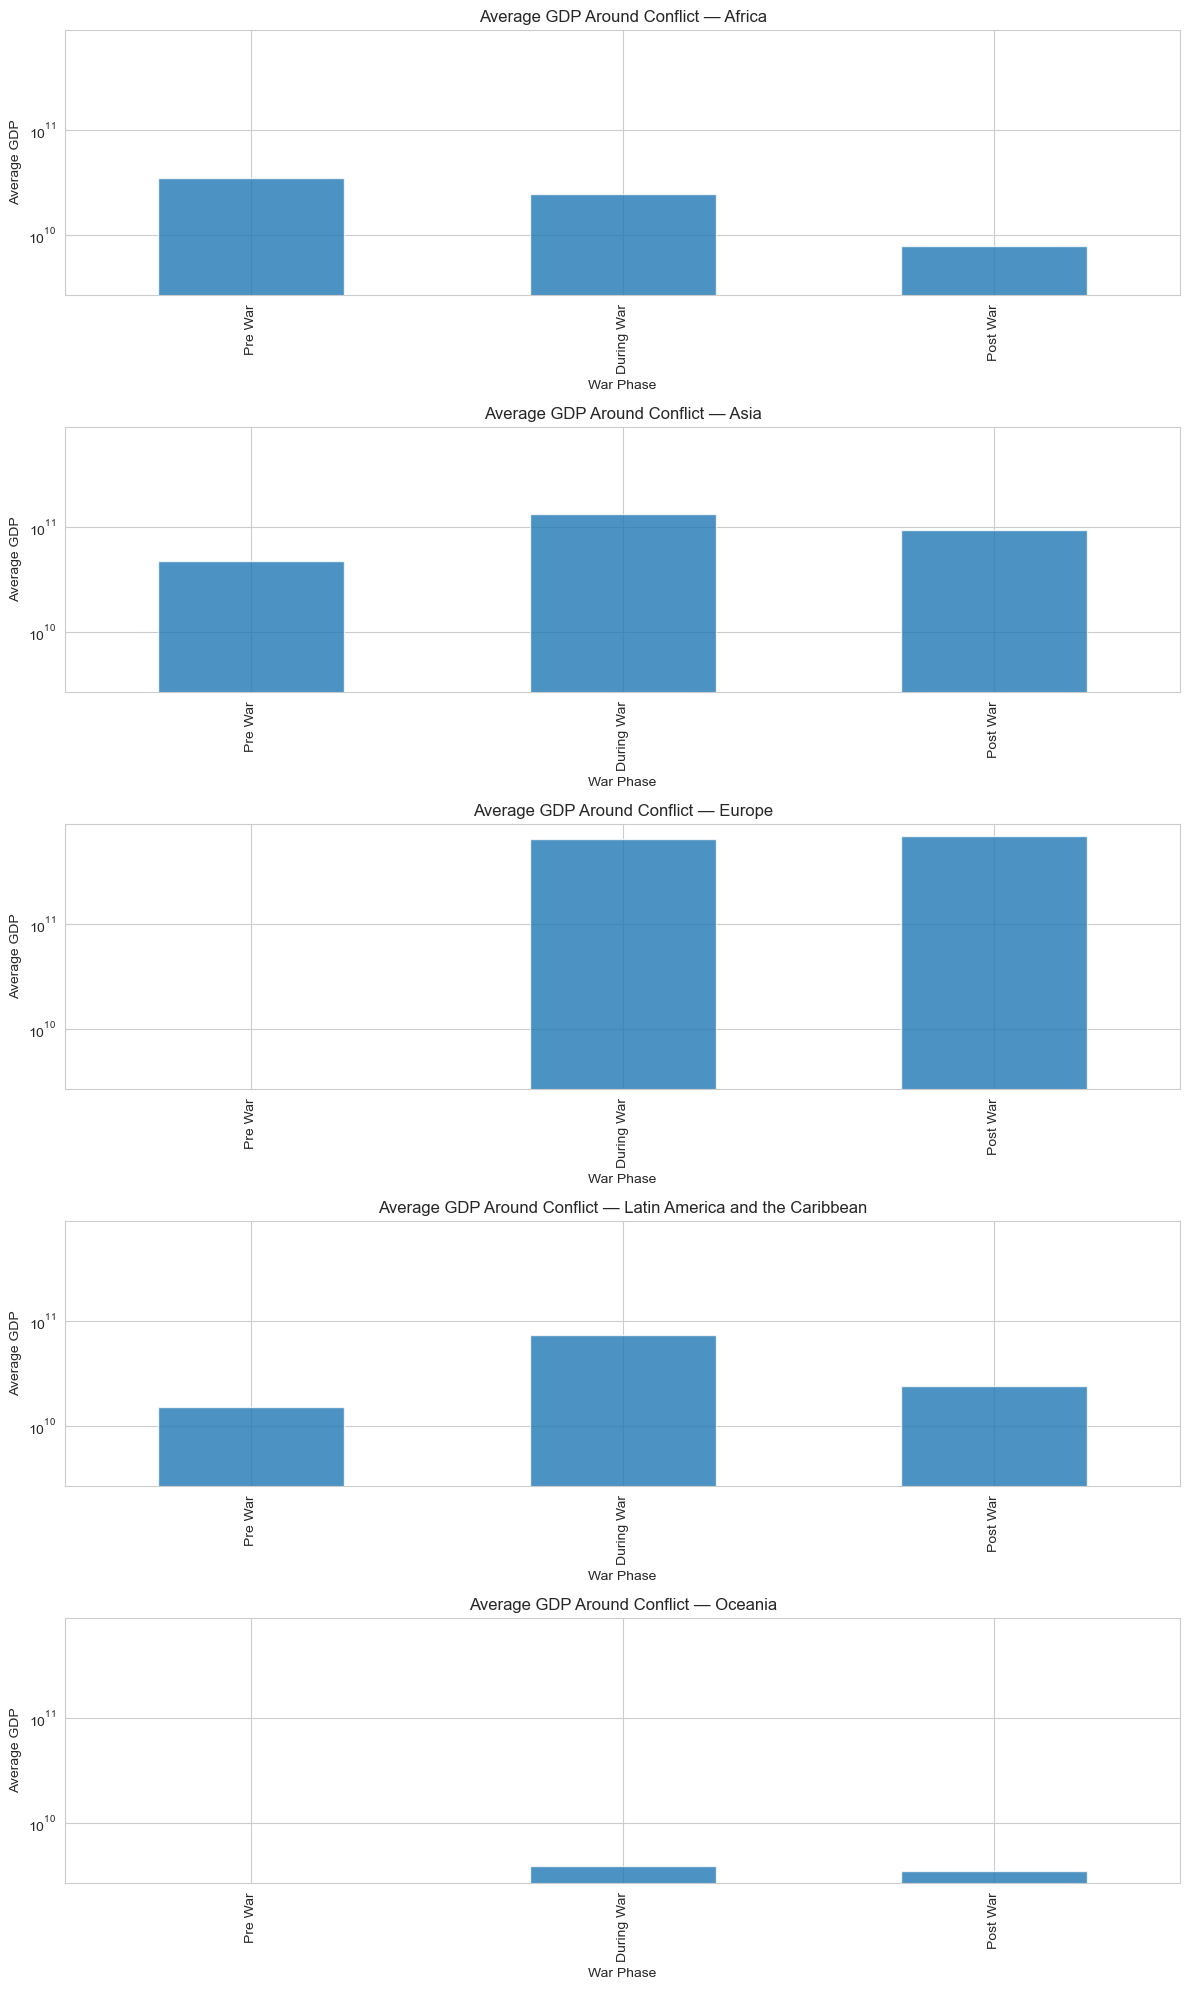

In [160]:
#9
df = df.sort_values(["country","year"])
df["conflict_prev"] = df.groupby("country")["conflict_present"].shift(1)
df["conflict_next"] = df.groupby("country")["conflict_present"].shift(-1)

# Define war phases
def war_phase(row):
    if row["conflict_present"] == 1:
        return "During War"
    elif row["conflict_prev"] == 1:
        return "Post War"
    elif row["conflict_next"] == 1:
        return "Pre War"
    else:
        return "No Conflict"

df["war_phase"] = df.apply(war_phase, axis=1)

# Select only conflict countries (Pre/During/Post)
war_data = df[df["war_phase"].isin(["Pre War","During War","Post War"])]

# Aggregate GDP by region and war phase
gdp_region_phase = war_data.groupby(["un_region","war_phase"])["gdp"].mean()

gdp_region_phase = gdp_region_phase.reset_index()

# Plot GDP by war phase per region
regions = gdp_region_phase["un_region"].unique()
war_phases = ["Pre War","During War","Post War"]

fig, axes = plt.subplots(len(regions), 1, figsize=(12, 4*len(regions)), sharey=True)

for i, region in enumerate(regions):
    data = gdp_region_phase[gdp_region_phase["un_region"] == region]
    # Ensure war phase order
    data = data.set_index("war_phase").reindex(war_phases)
    
    data["gdp"].plot(kind="bar", alpha=0.8, ax=axes[i])
    axes[i].set_title(f"Average GDP Around Conflict — {region}")
    axes[i].set_ylabel("Average GDP")
    axes[i].set_xlabel("War Phase")
    axes[i].set_yscale("log") 

plt.tight_layout()
plt.show()

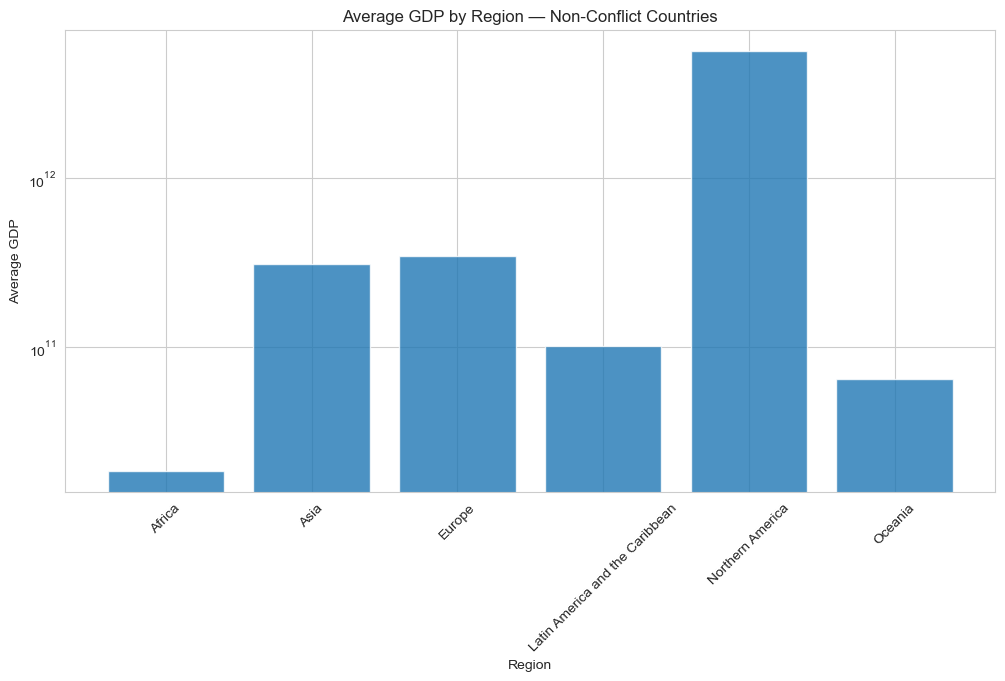

In [161]:
#10
df = df.sort_values(["country","year"])

# Select only non-conflict years
no_conflict_df = df[df["conflict_present"] == 0]

# Aggregate average GDP by region
gdp_no_conflict = no_conflict_df.groupby("un_region")["gdp"].mean().reset_index()

plt.figure(figsize=(12,6))
plt.bar(gdp_no_conflict["un_region"], gdp_no_conflict["gdp"], alpha=0.8)
plt.title("Average GDP by Region — Non-Conflict Countries")
plt.ylabel("Average GDP")
plt.xlabel("Region")
plt.yscale("log")  
plt.xticks(rotation=45)
plt.show()

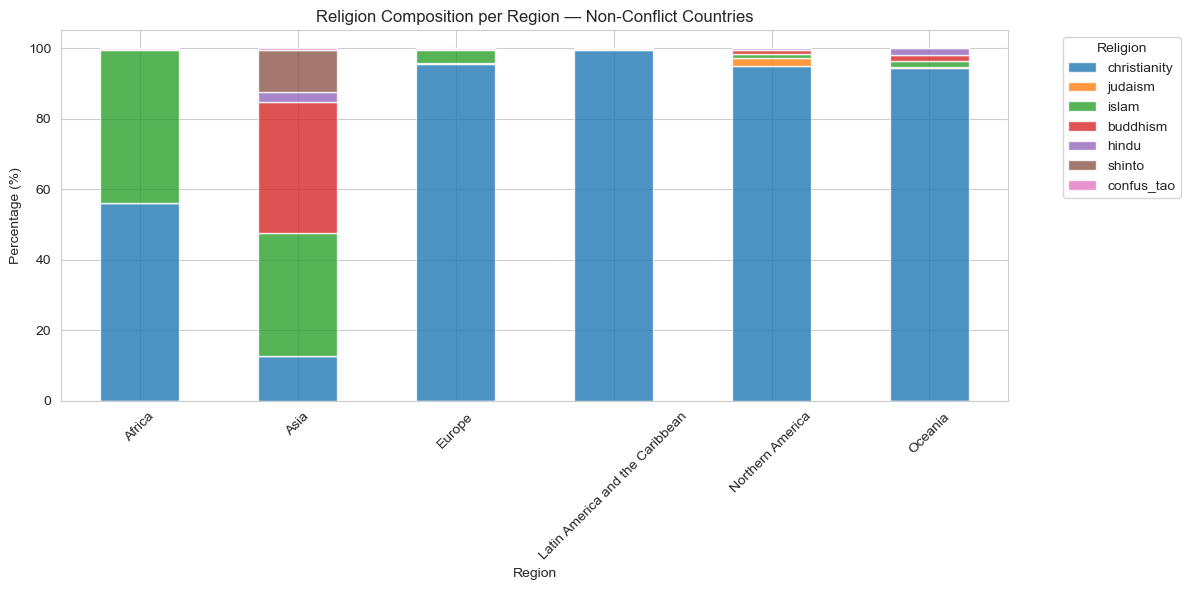

In [162]:
#11
religion = ["christianity", "judaism", "islam", "buddhism", "hindu", "shinto", "confus_tao"]

# Filter only non-conflict countries/years
no_conflict_df = df[df["conflict_present"] == 0]

# Aggregate religion totals by region
religion_region = no_conflict_df.groupby("un_region")[religion].sum()

religion_region_pct = religion_region.div(religion_region.sum(axis=1), axis=0) * 100

religion_region_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    alpha=0.8
)

plt.title("Religion Composition per Region — Non-Conflict Countries")
plt.ylabel("Percentage (%)")
plt.xlabel("Region")
plt.legend(title="Religion", bbox_to_anchor=(1.05,1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

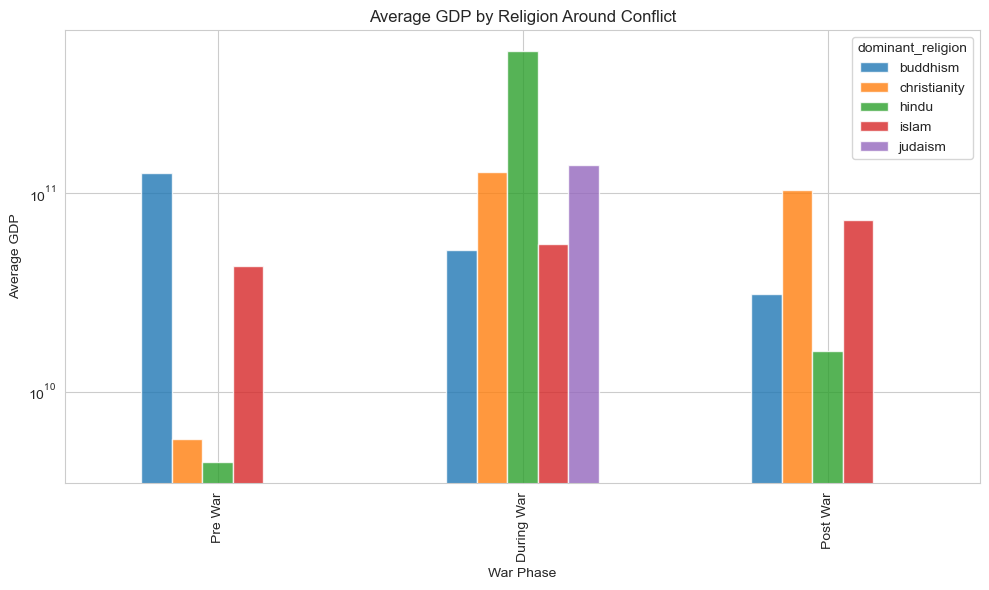

In [166]:
#12
war_df = df[df["war_phase"].isin(["Pre War","During War","Post War"])]

# average GDP by war phase and dominant religion
gdp_phase_religion = (
    war_df.groupby(["war_phase","dominant_religion"])["gdp"]
    .mean()
    .reset_index()
)

# reshape for plotting
gdp_pivot = gdp_phase_religion.pivot(
    index="war_phase",
    columns="dominant_religion",
    values="gdp"
)

# ensure correct order
war_phases = ["Pre War","During War","Post War"]
gdp_pivot = gdp_pivot.reindex(war_phases)

# plot
fig, ax = plt.subplots(figsize=(10,6))

gdp_pivot.plot(
    kind="bar",
    ax=ax,
    alpha=0.8
)

ax.set_title("Average GDP by Religion Around Conflict")
ax.set_ylabel("Average GDP")
ax.set_xlabel("War Phase")

# GDP values vary a lot → log scale helps
ax.set_yscale("log")

plt.tight_layout()
plt.show()

In [240]:
religion_cols = ["christianity","judaism","islam","buddhism","hindu","shinto","confus_tao"]

df["religious_population"] = df[religion].sum(axis=1)

# ensure religious population cannot exceed population
df["religious_population"] = df[["religious_population","population"]].min(axis=1)
df["religiosity"] = df["religious_population"] / df["population"]

df["gdp_per_capita"] = df["gdp"] / df["population"]

# create GDP categories
df["gdp_group"] = pd.qcut(df["gdp_per_capita"], 3,
                          labels=["Low GDP","Medium GDP","High GDP"])

table = df.groupby("gdp_group").agg(
    avg_gdp_per_capita=("gdp_per_capita","mean"),
    avg_religiosity=("religiosity","mean"),
    countries=("country","nunique")
)

print(table)

            avg_gdp_per_capita  avg_religiosity  countries
gdp_group                                                 
Low GDP             539.932353         0.830548         76
Medium GDP         2843.746540         0.876120         91
High GDP          26785.864319         0.863753         77


/var/folders/lx/2q1l_q_x1fscpnxy_nz3nf6m0000gn/T/ipykernel_7051/1079732755.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = df.groupby("gdp_group").agg(


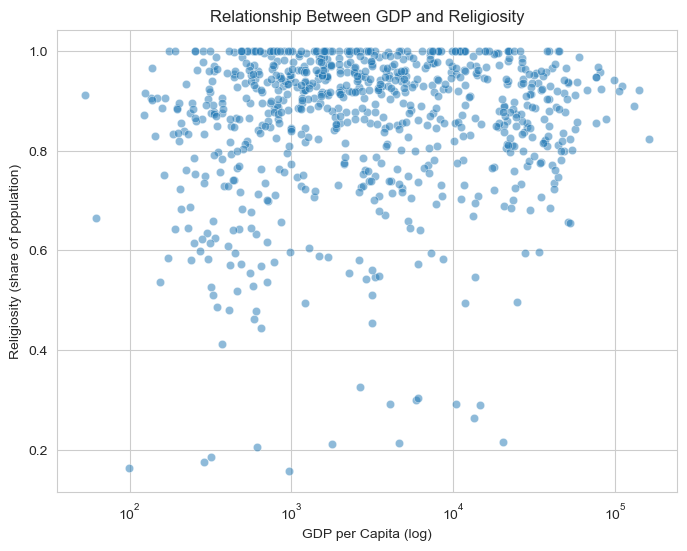

In [241]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="gdp_per_capita",
    y="religiosity",
    alpha=0.5
)

plt.xscale("log")
plt.xlabel("GDP per Capita (log)")
plt.ylabel("Religiosity (share of population)")
plt.title("Relationship Between GDP and Religiosity")

plt.show()

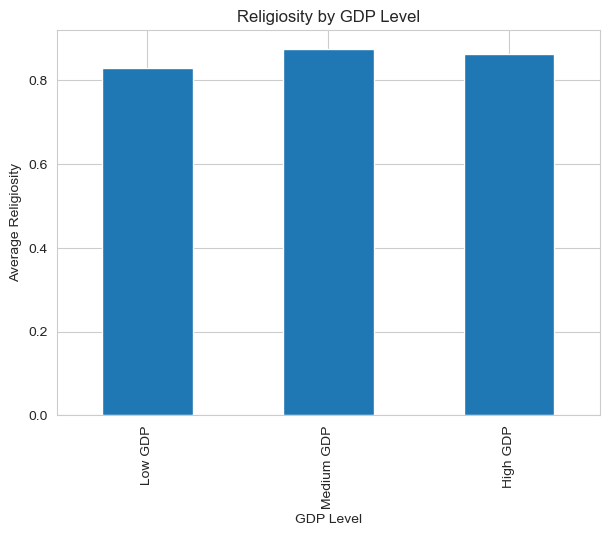

In [242]:
table.reset_index().plot(
    x="gdp_group",
    y="avg_religiosity",
    kind="bar",
    legend=False,
    figsize=(7,5)
)

plt.ylabel("Average Religiosity")
plt.xlabel("GDP Level")
plt.title("Religiosity by GDP Level")

plt.show()

In [ ]:
#2 - shows the GDP development per religion mirrored by conflict size, 
#5 & 6 - show religion share for war involved regions and non war regions + GDP development for the same division,
#7 - shows pre/during/post war religion share in war countries + #12 to show average gdp per/during/post war in war countries

# Conclusion:
# There is some correlation between religion, conflict, and GDP in the dataset, but the patterns appear to be driven mainly by regional economic development and geopolitical factors rather than religion itse
# data suggests:

# There is no clear direct causal link between religion and GDP. 
# GDP growth is more strongly linked to conflict exposure than religion and it likely reflects regional geopolitical factors.

# Conflict has a stronger negative relationship with GDP.

# Differences across religions are largely explained by regional economic and political factors.

# Conflicts correlate with shifts in dominant religion shares, especially toward Islam due to different patterns such as migration and displacement. For instance, while the share of Islamic countries in war is higher, the share of Islam population increases in non-war countries which might be directly influenced by displacement.